# IND320 Project work, part 1: Dashboard basics

Haakon Risbråthe, autumn 2026

This notebook looks at weekly data about the water reservoirs in Norway. The same data is shown in a Streamlit app.

- GitHub repository: <https://github.com/Haakon5555/ind320-haakon5555>
- Streamlit app: <https://ind320-haakon5555-bfhbsiaysptxoqxqkwr8o4.streamlit.app/>
- Data: [reservoirs.csv](https://github.com/khliland/IND320/blob/main/D2Dbook/data/reservoirs.csv) from the course repository

## How to run

The notebook and the app read the same file, `data/reservoirs.csv`. It is a copy of the course file and it has not been changed.

Open the notebook from the project folder and run all cells from the top. It needs Pandas and Matplotlib.

To start the app, run these commands in the project folder:

```bash
pip install -r requirements.txt
python -m streamlit run app.py
```

## 1. Read the data

The CSV file is read with Pandas. The first five rows show what the table looks like.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# The CSV file is in the data folder of the project.
DATA_PATH = Path("data/reservoirs.csv")
if not DATA_PATH.is_file():
    raise FileNotFoundError("Open the notebook from the project folder containing data/reservoirs.csv.")

# Read the file. This table keeps the original Norwegian column names.
reservoirs_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {len(reservoirs_raw):,} rows and {len(reservoirs_raw.columns)} columns.")
reservoirs_raw.head()

Loaded 14,877 rows and 11 columns.


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


**What is in the file?**

Each row is one week for one area. The area is given by `omrType` and `omrnr` together.

There are nine areas, and each of them has 1,653 weeks of data:

- **NO 0** is all of Norway.
- **EL 1 to EL 5** are the five electricity price areas.
- **VASS 1 to VASS 3** are water regions (vassdragsområder).

The column names and area codes are the same as in the [open reservoir statistics from NVE](https://biapi.nve.no/magasinstatistikk/swagger/index.html).

The areas overlap. The capacities of the five EL areas add up to 87.44 TWh, and so do the three VASS areas. That is the same as the capacity of NO 0. So NO 0 is already the total, and the areas should not be added together.

## 2. Rename the columns

The column names in the file are Norwegian. The cell below makes a copy of the table with English names. The original table is not changed.

In [2]:
# Make a copy of the table with English column names.
reservoirs = reservoirs_raw.rename(columns={
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_ratio",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_ratio",
    "endring_fyllingsgrad": "change_in_filling_ratio"
})

# Show the new column names.
reservoirs.columns.tolist()

['date',
 'area_type',
 'area_number',
 'iso_year',
 'iso_week',
 'filling_ratio',
 'capacity_twh',
 'stored_energy_twh',
 'next_publication_date',
 'previous_week_filling_ratio',
 'change_in_filling_ratio']

**What the columns mean**

| Column | Meaning | Unit |
| --- | --- | --- |
| `date` | Date of the weekly measurement | date |
| `area_type` | Type of area: NO, EL or VASS | label |
| `area_number` | Number of the area | label |
| `iso_year` | Year that the week belongs to | year |
| `iso_week` | Week number | week |
| `filling_ratio` | How full the reservoirs are | fraction (0.8 = 80%) |
| `capacity_twh` | Energy the reservoirs hold when they are full | TWh |
| `stored_energy_twh` | Energy in the reservoirs this week | TWh |
| `next_publication_date` | When the next numbers are published | date and time |
| `previous_week_filling_ratio` | Filling ratio the week before | fraction |
| `change_in_filling_ratio` | Change in filling ratio since the week before | fraction (0.01 = 1 percentage point) |

Five of the columns are measurements: the two filling ratios, capacity, stored energy and weekly change. The other six are dates and labels. They tell which week and which area a row belongs to.

## 3. Look at the data

The cell below shows the first rows, the data type of each column and the number of missing values.

In [3]:
# First five rows with the new column names.
display(reservoirs.head())

# Number of rows, data types and how many values each column has.
reservoirs.info()

# Number of missing values in each column.
display(reservoirs.isna().sum())

,date,area_type,area_number,iso_year,iso_week,filling_ratio,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_ratio,change_in_filling_ratio
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         14877 non-null  object 
 1   area_type                    14877 non-null  object 
 2   area_number                  14877 non-null  int64  
 3   iso_year                     14877 non-null  int64  
 4   iso_week                     14877 non-null  int64  
 5   filling_ratio                14877 non-null  float64
 6   capacity_twh                 14877 non-null  float64
 7   stored_energy_twh            14877 non-null  float64
 8   next_publication_date        14877 non-null  object 
 9   previous_week_filling_ratio  14877 non-null  float64
 10  change_in_filling_ratio      14877 non-null  float64
dtypes: float64(5), int64(3), object(3)
memory usage: 1.2+ MB


date                           0
area_type                      0
area_number                    0
iso_year                       0
iso_week                       0
filling_ratio                  0
capacity_twh                   0
stored_energy_twh              0
next_publication_date          0
previous_week_filling_ratio    0
change_in_filling_ratio        0
dtype: int64

**What the data looks like**

- The table has 14,877 rows and 11 columns. No values are missing, and no date and area is there twice.
- The data goes from 8 January 1995 to 6 September 2026, with one row per week for each area.
- The rows are not sorted by date, and the dates are stored as text. Before plotting, the dates are converted to real dates and sorted.
- `next_publication_date` is `0001-01-01` in 11,322 rows. This is a placeholder and not a real date, but Pandas does not count it as missing. The app shows it as "Not reported".
- Two values of `filling_ratio` are above 1.0. Both are from EL 1 in August 2023. They are kept as they are.
- The first week in the file (8 January 1995) has a very large change for most areas. For Norway it is -14.4 percentage points. In all the other weeks the largest fall for Norway is 4.2. The first value looks wrong, but it is kept as it is.

## 4. Plot each column separately

There is one figure for each of the five measurement columns, with one line for each area. The dates are used on the x-axis and the area is used in the legend. The other columns (ISO year, ISO week and publication date) are not plotted, because they are not measurements.

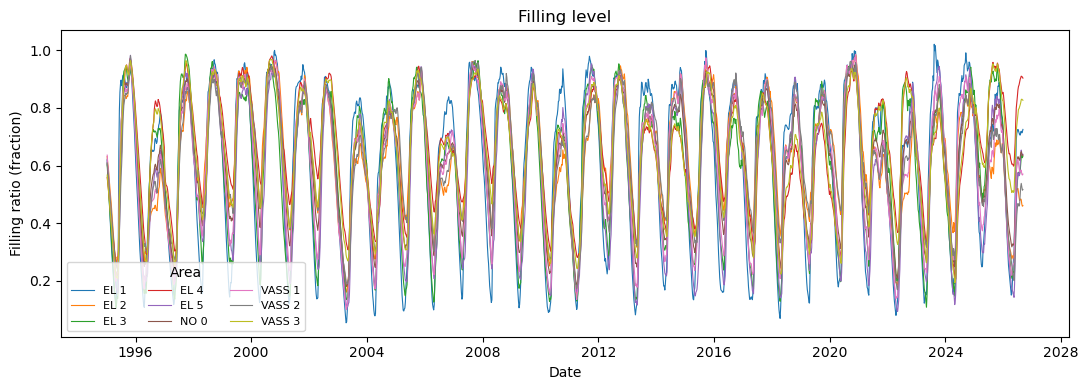

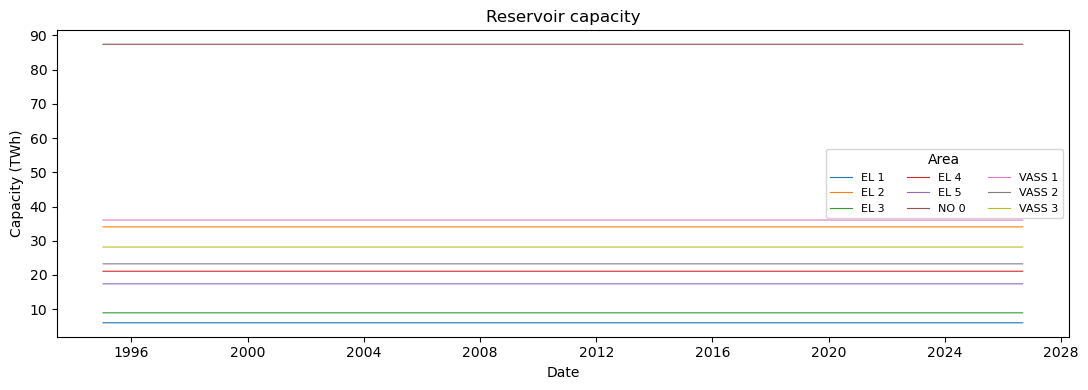

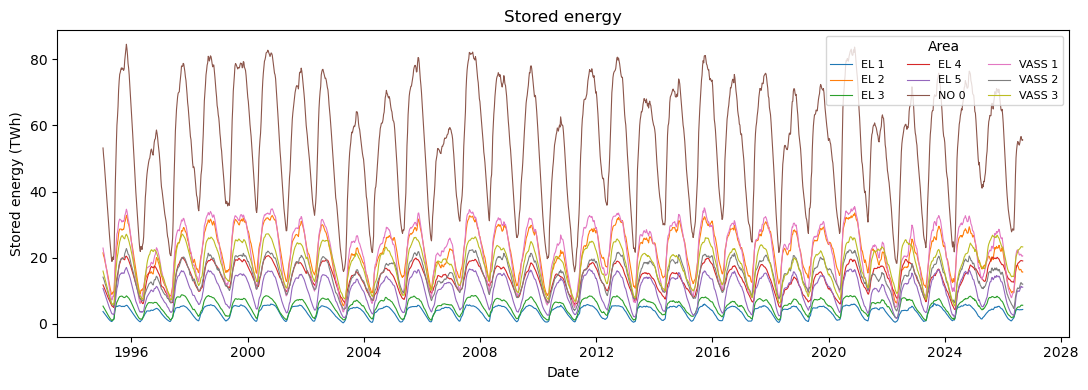

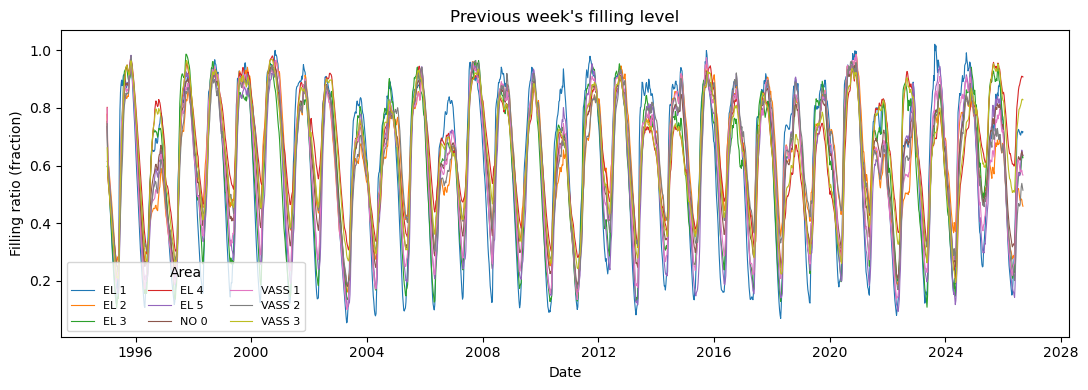

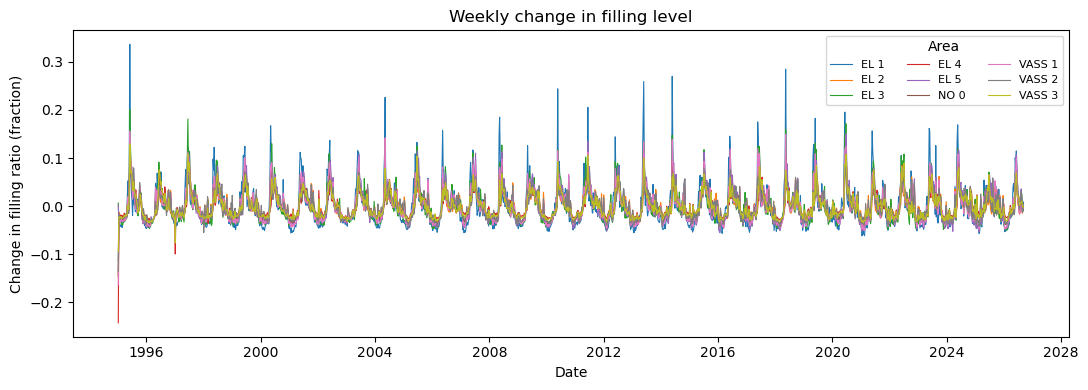

In [4]:
# Make a copy where the dates are real dates, sorted from oldest to newest.
plot_data = reservoirs.copy()
plot_data["date"] = pd.to_datetime(plot_data["date"])
plot_data = plot_data.sort_values("date")

# Title and y-axis label for each of the five measurement columns.
measurement_labels = {
    "filling_ratio": ("Filling level", "Filling ratio (fraction)"),
    "capacity_twh": ("Reservoir capacity", "Capacity (TWh)"),
    "stored_energy_twh": ("Stored energy", "Stored energy (TWh)"),
    "previous_week_filling_ratio": ("Previous week's filling level", "Filling ratio (fraction)"),
    "change_in_filling_ratio": ("Weekly change in filling level", "Change in filling ratio (fraction)"),
}
measurement_columns = list(measurement_labels)

# One figure per column.
for column, (title, unit_label) in measurement_labels.items():
    fig, ax = plt.subplots(figsize=(11, 4))
    # One line per area. groupby keeps the areas apart.
    for (kind, number), area in plot_data.groupby(["area_type", "area_number"]):
        ax.plot(area["date"], area[column], label=f"{kind} {number}", linewidth=0.8)
    ax.set(title=title, xlabel="Date", ylabel=unit_label)
    ax.legend(title="Area", ncol=3, fontsize=8)
    fig.tight_layout()
    plt.show()

**What the figures show**

- **Filling level:** The level goes up and down once every year. For Norway (NO 0) the lowest month is April, with 33% on average, and the highest is October, with 82%. EL 1 is a little above 1.0 in August 2023.
- **Capacity:** The lines are flat, because the capacity does not change in this file. Norway has 87.44 TWh in total. EL 1 is the smallest area with 6.00 TWh.
- **Stored energy:** The same yearly pattern as the filling level, but in TWh. A large area has a high value even when it is not very full. So this figure also shows how large the areas are.
- **Previous week's filling level:** Almost the same figure as the first one, because it is the same numbers moved one week.
- **Weekly change:** Values above zero mean that the level went up, and values below zero mean that it went down. 0.05 is five percentage points. Most weeks the change is small. The largest increase for Norway is 12.5 percentage points, in June 1995.

## 5. Plot all columns together

The five measurements have different units and very different sizes. Capacity is 87 TWh, and a weekly change is often around 0.01. On one shared y-axis the small values would look like a flat line.

The figure below has three panels with the same date axis, one for each unit:

1. filling level this week and the week before, in percent
2. capacity and stored energy, in TWh
3. weekly change, in percentage points

The figure only shows Norway (NO 0). With all nine areas there would be 45 lines.

The six columns with dates and labels are shown in a small table below the figure.

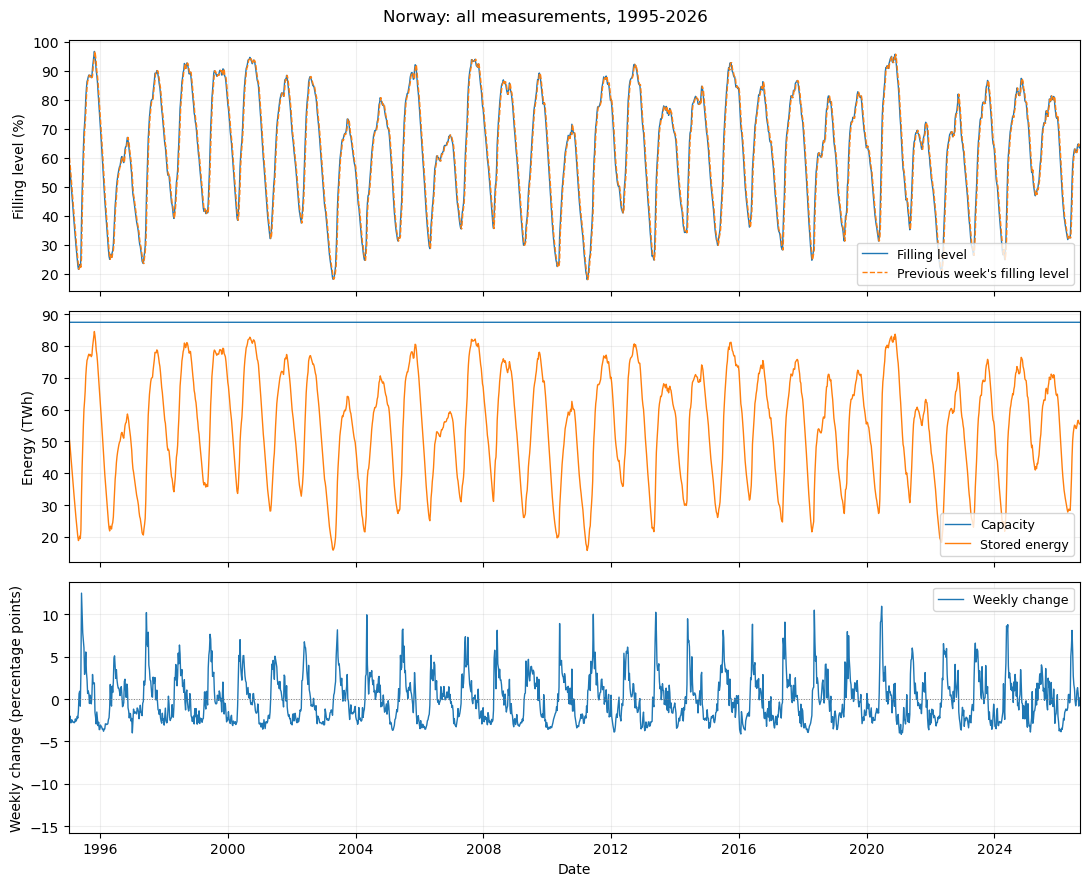

,date,area_type,area_number,iso_year,iso_week,next_publication_date
8501,1995-01-08,NO,0,1995,1,Not reported
8768,1995-01-15,NO,0,1995,2,Not reported
9035,1995-01-22,NO,0,1995,3,Not reported
8870,1995-01-29,NO,0,1995,4,Not reported
8316,1995-02-05,NO,0,1995,5,Not reported


In [5]:
# Use only the rows for Norway (NO 0).
norway = plot_data.loc[
    (plot_data["area_type"] == "NO") & (plot_data["area_number"] == 0)
].copy()

# Three groups, one per panel: column, label and what to multiply with.
# Fractions are multiplied by 100 to get percent and percentage points.
groups = [
    ([("filling_ratio", "Filling level", 100),
      ("previous_week_filling_ratio", "Previous week's filling level", 100)], "Filling level (%)"),
    ([("capacity_twh", "Capacity", 1),
      ("stored_energy_twh", "Stored energy", 1)], "Energy (TWh)"),
    ([("change_in_filling_ratio", "Weekly change", 100)], "Weekly change (percentage points)"),
]
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle("Norway: all measurements, 1995-2026")
for ax, (series, unit_label) in zip(axes, groups):
    for column, label, multiplier in series:
        ax.plot(
            norway["date"], norway[column] * multiplier, label=label,
            # Dashed line for last week's level, since it lies close to this week's.
            linewidth=1, linestyle="--" if column == "previous_week_filling_ratio" else "-",
        )
    ax.set_ylabel(unit_label)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
# Zero line in the bottom panel, to see if the level went up or down.
axes[-1].axhline(0, color="gray", linewidth=0.7, linestyle=":")
axes[-1].set_xlabel("Date")
axes[-1].set_xlim(norway["date"].min(), norway["date"].max())
fig.tight_layout()
plt.show()

# Show the first rows of the six columns with dates and labels.
metadata_columns = [column for column in norway.columns if column not in measurement_columns]
metadata_preview = norway[metadata_columns].head().copy()
# Year 0001 is a placeholder in the file, so there is no real date.
metadata_preview["next_publication_date"] = metadata_preview["next_publication_date"].replace(
    "0001-01-01T00:00:00", "Not reported"
)
display(metadata_preview)

**What the combined figure shows**

- **Top panel:** The filling level this week and the week before are almost on top of each other.
- **Middle panel:** The capacity is a flat line at 87.44 TWh. The stored energy goes up and down below it.
- **Bottom panel:** The weekly change moves around zero. It is above zero when the reservoirs fill up and below zero when they are emptied. The axis goes down to -15 because of the first week in 1995 (see section 3).

### Filling level and stored energy

The next figure shows filling level and stored energy in the same plot, with one y-axis on each side.

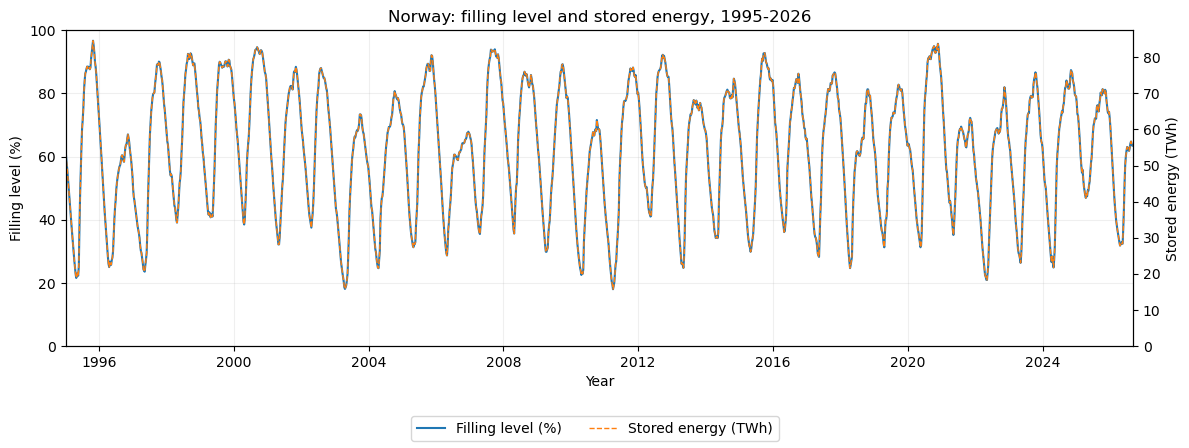

In [6]:
# Two y-axes in the same plot: percent on the left and TWh on the right.
fig, ax_left = plt.subplots(figsize=(12, 4.5))
ax_right = ax_left.twinx()
filling_line, = ax_left.plot(
    norway["date"], norway["filling_ratio"] * 100,
    color="tab:blue", linewidth=1.5, label="Filling level (%)"
)
energy_line, = ax_right.plot(
    norway["date"], norway["stored_energy_twh"],
    color="tab:orange", linestyle="--", linewidth=1, label="Stored energy (TWh)"
)

# The right axis stops at the capacity, so 100% and full capacity are at the same height.
ax_left.set_ylim(0, 100)
ax_right.set_ylim(0, norway["capacity_twh"].iloc[0])
ax_left.set_ylabel("Filling level (%)")
ax_right.set_ylabel("Stored energy (TWh)")
ax_left.set_xlabel("Year")
ax_left.set_xlim(norway["date"].min(), norway["date"].max())
ax_left.set_title("Norway: filling level and stored energy, 1995-2026")
ax_left.grid(alpha=0.2)

# One legend for both lines, below the figure.
fig.legend(handles=[filling_line, energy_line], loc="lower center", ncol=2)
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

**What the figure shows**

The left axis is the filling level in percent. The right axis is the stored energy in TWh. The right axis stops at the capacity (87.44 TWh), so 100% on the left is at the same height as full capacity on the right.

The two lines lie on top of each other. The reason is that stored energy is the filling ratio times the capacity, and the capacity does not change. So the two columns show the same thing in two different units.

## 6. Streamlit app

The app has four pages. Streamlit makes the menu from `app.py` and the files in the `pages` folder.

| Page | File | Content |
| --- | --- | --- |
| Home | `app.py` | Short introduction |
| Data | `pages/1_Data.py` | Table with the first month, one row per CSV column |
| Plots | `pages/2_Plots.py` | Plot with a column menu and a month slider |
| About | `pages/3_About.py` | About the project and the data source |

**Reading the data.** The Data and Plots pages use `load_data()` in `data_loader.py`. It reads the CSV file, renames the columns and sorts the rows by date. The function has `@st.cache_data`, so the file is read once and the result is used again when a page reruns.

**Data page.** The first month is January 1995, with four weeks of data for Norway. Each of the eleven CSV columns is one row in the table. The five measurement rows have a small line chart made with `LineChartColumn`.

**Plots page.** The menu (`st.selectbox`) has all eleven columns and the choice "All columns together", which gives the same three panels as in section 5. Date and label columns are shown in a table and not as a plot. The slider (`st.select_slider`) chooses the first and last month, and starts with only January 1995.

## 7. Work log

The project started with a simple app with four pages. The app files were first uploaded to GitHub, where the project code is stored online. Streamlit Cloud then used the files from GitHub to run the app and make it available through a web link. This first version was only a starting point. It was published early to check that GitHub and Streamlit Cloud worked together. Work then continued on my own computer, where the data analysis, tables and plots were added to the notebook and the app.

**Jupyter Notebook.** The notebook reads the CSV file with Pandas, gives the columns English names and shows the first rows, the data types and the missing values. At first the file looked clean, with no missing values. But the column with the next publication date has year 0001 in most rows, so a count of missing values does not tell everything. The rows were not sorted by date either, so the dates had to be converted and sorted before plotting.

One difficult part was to plot all the columns together. Capacity is 87 TWh and a weekly change is around 0.01, so one shared y-axis does not work. The solution was three panels, one for each unit. I also asked for a figure with filling level and stored energy on two y-axes. It shows that the two columns are the same curve in different units, because the capacity does not change.

**Streamlit.** The app has the pages Home, Data, Plots and About (see section 6). Streamlit runs the whole page file again after every click. Because of this the data is read in one function with `@st.cache_data`, so the file is not read again each time.

**Problems.** The app on my own machine and the published app are two different things. The published app only changes after a push to GitHub, so it showed the starter version until the new code was pushed. The local server also had to be restarted while the app was tested. It was also some work to keep the notebook and the app equal, with the same column names and the same units in both.

## 8. AI usage

I personally try to use AI as much and as effectively as possible to keep up with developments in the technology. For this project, I mainly used OpenAI Codex in the Codex desktop app.

I prefer to keep the notebook and the other code files open in tabs in the side panel. This lets me follow the work from start to finish, discuss what needs to be implemented and see the changes directly in the files. I can also edit and adapt the code and text myself along the way.

I do not write the code line by line myself. Codex generated most of the code and the first drafts of the explanations and the work log. It also helped test the app and check results against the data. My role is to read through what is generated, ask for explanations when something is unclear and request changes along the way so the result answers the assignment better.

My aim is to understand everything that is generated, including what the code does and why it is used. I am responsible for checking the final content and making sure I can explain it.